In [1]:
# FIXED for the 1Dheatnn 
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt 
import time

torch.set_default_dtype(torch.float64)
# define Net()
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.layers = nn.ModuleList()
        self.layers.append(nn.Linear(d_in, nodes))  # First layer
        for _ in range(1, layers):  # Remaining hidden layers
            self.layers.append(nn.Linear(nodes, nodes))
        self.out = nn.Linear(nodes, d_out)
    def forward(self, x):
        for layer in self.layers:
            x = torch.sigmoid(layer(x))  # Or use F.relu if preferred
        return self.out(x)

# class Net(nn.Module):
#     def __init__(self):
#         super(Net, self).__init__()
#         self.fc1 = nn.Linear(d_in,nodes)
#         if layers > 1:
##            self.fc2 = nn.Linear(nodes,nodes)
#         if layers > 2:
#             self.fc3 = nn.Linear(nodes,nodes)
#         if layers > 3:
#             self.fc4 = nn.Linear(nodes,nodes)
#         if layers > 4:
#             self.fc5 = nn.Linear(nodes,nodes)
#         if layers > 5:
#             self.fc6 = nn.Linear(nodes,nodes)
#         if layers > 6:
#             self.fc7 = nn.Linear(nodes,nodes)
#         if layers > 7:
#             self.fc8 = nn.Linear(nodes,nodes)
#         self.fcn = nn.Linear(nodes,1)
#     def forward(self, x):
#         x = F.sigmoid(self.fc1(x)) #x = F.relu(self.fc1(x))
#         if layers > 1:
#             x = F.sigmoid(self.fc2(x))
#         if layers > 2:
#             x = F.sigmoid(self.fc3(x))
#         if layers > 3:
#             x = F.sigmoid(self.fc4(x))
#         if layers > 4:
#             x = F.sigmoid(self.fc5(x))
#         if layers > 5:
#             x = F.sigmoid(self.fc6(x))
#         if layers > 6:
#             x = F.sigmoid(self.fc7(x))
#         if layers > 7:
#             x = F.sigmoid(self.fc8(x))
#         return self.fcn(x)

# build the NN
def build_nn():
    model = Net()
    optimizer = optim.AdamW(model.parameters(), lr=lr, eps=eps,
        betas=betas,weight_decay=wd)
    return model, optimizer

# rebuild the NN from (model_dict, optimizer_dict) 
def rebuild_nn():
    model = Net()
    optimizer = optim.AdamW(model.parameters(), lr=lr, eps=eps,
        betas=betas,weight_decay=wd)
    if 'model_dict' in globals():
        model.load_state_dict(model_dict)
    else:
        print('**** Not enough info to recover the model ****')
    if 'optimizer_dict' in globals():
        optimizer.load_state_dict(optimizer_dict)
    else:
        print('**** Not enough info to recover the optimizer ****')
    return model, optimizer

# print parameters, model, optimer
def print_params():
    print('Structure of neural network: ',model) # print the model
    print('Optimizer:  ',optimizer)
    print(f'parameters: d_in = {d_in}, d_out = {d_out}, '\
         f'layers = {layers}, nodes = {nodes}')
    print(f'    tol = {tol:.4e}, epochs = {epochs}, seg_size = {seg_size}, epoch_0 = {epoch_0}')
    print(f'    N_train = {N}, N_test = {N_test}')
    print(f'    output file: {out_file:s}\n')


In [2]:
# define f(x)

def f(x): # R^5 to R^1
    y=torch.reshape(torch.sin(torch.cos(x[:,0])+x[:,1]+torch.cos(x[:,2])
        +x[:,3]+torch.cos(x[:,4])), (x.size(0),1) )
    return y

# generate training/testing data
def generate_data(n):
    x = -0.5*L+L*torch.rand((n,d_in))
    y = f(x) # n data points
    return x, y


In [3]:
# train the NN
def train_nn():
    tolc = tol # tolc is the current tolerance 
    loss_curr_min=1.0e4 # the current minimum loss
    epochs_soft = epochs-2*seg_size # soft cap on the number of epochs
        # after reaching epochs_soft, stop when loss <= loss_curr_min
    epochs_hard = epochs+40*seg_size
    loss_v = np.zeros(epochs_hard, dtype=float) # for training loss
    loss_test_v = np.zeros(epochs_hard, dtype=float) # for test loss
    # loss_v[i] contains the loss AFTER i epochs are COMPLETED (at the 
    # BEGINNING of the epoch with index i    
    #
    model.train(); start = time.time()
    for i in range(epochs_hard):
        optimizer.zero_grad() # zero the gradients
        loss = F.mse_loss(model(xtrain),ytrain) # train loss
        with torch.no_grad(): # no need for grad in loss_test!!!
            #loss_test = F.mse_loss(model(xtest),ytest) # test loss
            loss_v[i] = loss.item()
        #loss_test_v[i] = loss_test.item()
        #
        if (i+epoch_0)%seg_size == 0:
            loss_curr_min = min([np.min(loss_v[max(0, i+1-seg_size):i+1]),
                loss_curr_min]) # update loss_curr_min
            tolc = loss_curr_min if i>=epochs_soft else tol # revise tolc at i >= epochs_soft
            print(f'i = {i+epoch_0}, loss = {loss.item():.4e} '
                  f'loss_curr_min = {loss_curr_min:.4e}')
            current=time.time()
            print(f'Elapsed time = {current-start:.2f}s,  CA time = {time.ctime(current):s}')
        if loss.item() <= 1.4*tolc:
            loss_v=loss_v[0:i+1]
            #loss_test_v=loss_test_v[0:i+1]
            break
        loss.backward() # Back propagation to compute all gradients
        optimizer.step() # optimizer step (updating)
    # print more info after training
    current = time.time();
    msg_train=[]
    msg_train.append(f'Training info: tol_actual = {tolc:.4e}, '\
            f'epochs_actual = {epoch_0+loss_v.size-1}')
    msg_train.append(f'    loss_train(MSE) = {loss_v[-1]:.4e}')
    msg_train.append(f'    Elapsed time = {current-start:.2f}s,  '\
            f'CA time = {time.ctime(current):s}')
    return {'loss_v':loss_v, 'msg_train':msg_train}

# save model and key variables to a data file
def save_model_vars():
    np_vars = {name: val for name, val in globals().items()
            if isinstance(val, (float, int))}
    np_vars['model_dict'] = model.state_dict()
    np_vars['optimizer_dict'] = optimizer.state_dict()
    np_vars['epoch_0']=epoch_0+len(loss_v)-1
    #np_vars['msg_train']=msg_train; np_vars['msg_test']=msg_test
    torch.save(np_vars, out_file)


In [4]:
# test the trained model and plot figures
def test_and_plotting():
    # calculate and print training loss and testing loss (MSE)
    model.eval()
    with torch.no_grad():
        err_train=(model(xtrain)-ytrain).cpu().numpy()
            #
    msg_test = []
    msg_test.append(f'    rms_err_train = {np.sqrt(np.mean(err_train**2)):.4e}')
    msg_test.append(f'    max_err_train = {np.max(np.abs(err_train)):.4e}')
    #
    # plot training loss (MSE) vs epoch
    plt.figure(figsize=(4.8,3.6))
    plt.semilogy(np.arange(len(loss_v))/1000, loss_v,'b-')
    plt.xlabel('Epochs (in 1000s)')
    plt.ylabel('MSE of training')
    plt.xticks(rotation=0, ha='center')
    plt.title('Loss (MSE) vs epochs ')
    plt.savefig('fig_1.pdf',bbox_inches='tight')
    plt.grid(True)
    plt.show()
    
    plt.figure(figsize=(4.8,3.6))
    plt.hist(err_train, bins=200)
    plt.xlabel('Point-wise traning error')
    plt.ylabel('Count')
    plt.xticks(rotation=0, ha='center')
    plt.title('Distribution of point-wise error')
    plt.savefig('fig_2.pdf',bbox_inches='tight')
    plt.grid(True)
    plt.show()
    return {'err_train':err_train}


In [9]:
# set a dictionary of parameters
params_def = {'d_in':4, 'd_out':1, 'layers':4, 'nodes':64,
    'tol':0.5e-6, 'epochs':1000000, 'seg_size':1000, 'epoch_0':0,
    'lr':0.005, 'eps':1e-10, 'betas':(0.995, 0.999), 'wd':1e-4,
    'L':10, 'N':100000, 'N_test':100000,
    'out_file':f'./data/d_fv_tm.pt'} 
# use the default parameters above unless func_def_only ==1
if ('func_def_only' not in locals()) or (func_def_only != 1):
    for name in params_def:
        globals()[name] = params_def[name]
else: # if func_def_only ==1, use existing whenever possible
    for name in params_def:
        if name not in globals():
            globals()[name] = params_def[name]

sec_main = """
torch.manual_seed(42)
torch.cuda.manual_seed(42)
# Load the data
loaded_tensor = torch.load('./train/caseA_nt301_nz300_zc0.5.pt',weights_only=True) 
#
device = torch.device('cpu')

s = loaded_tensor['s']
tv = loaded_tensor['tv']
W = loaded_tensor['W']
kratio = loaded_tensor['kratio']
z_disv = loaded_tensor['z_disv']


train = torch.stack([s, tv, kratio, z_disv], dim=-1)

          
W = W.to(torch.float64)
xtrain = train.to(torch.float64)
ytrain = W


# torch.manual_seed(42) # This is for comparing with "fv_nn_cuda_v2"
# torch.cuda.manual_seed(42)
if start_new_nn == 1:
    model, optimizer = build_nn() # build a new model
    model = model.to(device)
    del start_new_nn
else:
    model, optimizer = rebuild_nn() # rebuild the model from saved data
    model = model.to(device)        
    for state in optimizer.state.values():
        for k, v in state.items():
            if isinstance(v, torch.Tensor):
                state[k] = v.to(device)
print(f'neural network model is on {next(model.parameters()).device}')
print_params() # print parameters
#
res_train = train_nn() # train the model
for key in res_train: # unpack res_train
    globals()[key] = res_train[key]
res_test = test_and_plotting() # test the model and plot results
for key in res_test: # unpack res_test
    globals()[key] = res_test[key]
#
print_params()
[print(msg) for msg in msg_train]
##[print(msg) for msg in msg_test]
save_model_vars() # save the model and variables in a dictionary
"""


neural network model is on cpu
Structure of neural network:  Net(
  (layers): ModuleList(
    (0): Linear(in_features=4, out_features=64, bias=True)
    (1-3): 3 x Linear(in_features=64, out_features=64, bias=True)
  )
  (out): Linear(in_features=64, out_features=1, bias=True)
)
Optimizer:   AdamW (
Parameter Group 0
    amsgrad: False
    betas: (0.995, 0.999)
    capturable: False
    differentiable: False
    eps: 1e-10
    foreach: None
    fused: None
    lr: 0.01
    maximize: False
    weight_decay: 0.0001
)
parameters: d_in = 4, d_out = 1, layers = 4, nodes = 64
    tol = 5.0000e-08, epochs = 10000000, seg_size = 1000, epoch_0 = 0
    N_train = 100000, N_test = 100000
    output file: ./data/caseA5e-08_nt300.pt

i = 0, loss = 1.0428e-01 loss_curr_min = 1.0428e-01
Elapsed time = 0.00s,  CA time = Thu Apr 23 21:44:25 2026
i = 1000, loss = 2.0542e-02 loss_curr_min = 2.0500e-02
Elapsed time = 4.05s,  CA time = Thu Apr 23 21:44:29 2026
i = 2000, loss = 2.0505e-02 loss_curr_min = 2.0

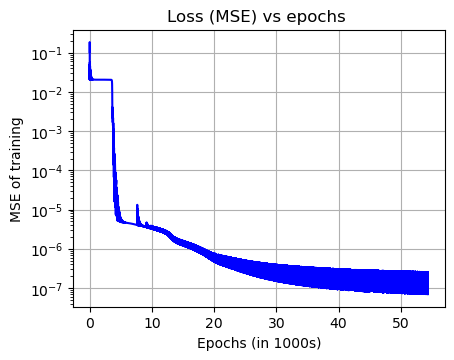

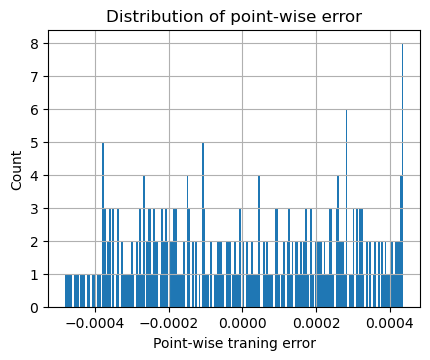

Structure of neural network:  Net(
  (layers): ModuleList(
    (0): Linear(in_features=4, out_features=64, bias=True)
    (1-3): 3 x Linear(in_features=64, out_features=64, bias=True)
  )
  (out): Linear(in_features=64, out_features=1, bias=True)
)
Optimizer:   AdamW (
Parameter Group 0
    amsgrad: False
    betas: (0.995, 0.999)
    capturable: False
    differentiable: False
    eps: 1e-10
    foreach: None
    fused: None
    lr: 0.01
    maximize: False
    weight_decay: 0.0001
)
parameters: d_in = 4, d_out = 1, layers = 4, nodes = 64
    tol = 5.0000e-08, epochs = 10000000, seg_size = 1000, epoch_0 = 0
    N_train = 100000, N_test = 100000
    output file: ./data/caseA5e-08_nt300.pt

Training info: tol_actual = 5.0000e-08, epochs_actual = 54368
    loss_train(MSE) = 6.9905e-08
    Elapsed time = 205.13s,  CA time = Thu Apr 23 21:47:50 2026


In [11]:
# run the code unless func_def_only ==1
if ('func_def_only' not in locals()) or (func_def_only != 1):
    start_new_nn = 1
    nt = 300
    lr = .01
    wd = .0001
    epochs = 10000000
    betas = (0.995, 0.999)
    tol = 5e-8
    start_new_nn = 1
    out_file= f'./data/caseA{tol}_nt{nt}.pt'
    exec(sec_main)


In [17]:
output = model(train)
error = torch.abs(output - W)
err_log = np.log10(np.clip(error.cpu().detach().numpy(), 1e-16, None))

z = loaded_tensor['z1']

Text(0, 0.5, '$\\varepsilon_{abs,W}$')

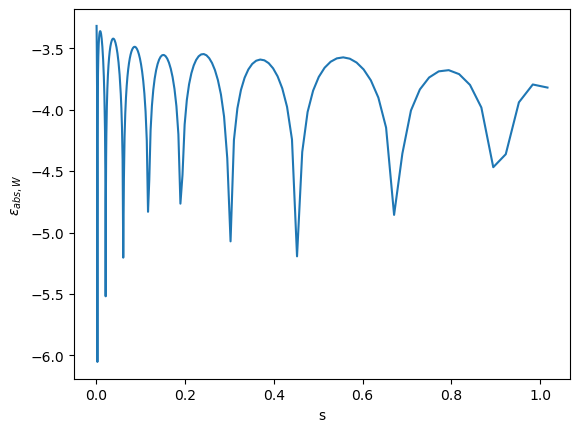

In [18]:
plt.plot(s,err_log)
plt.xlabel('s');plt.ylabel(r'$\varepsilon_{abs,W}$')


Text(0, 0.5, '$\\varepsilon_{abs,W}$')

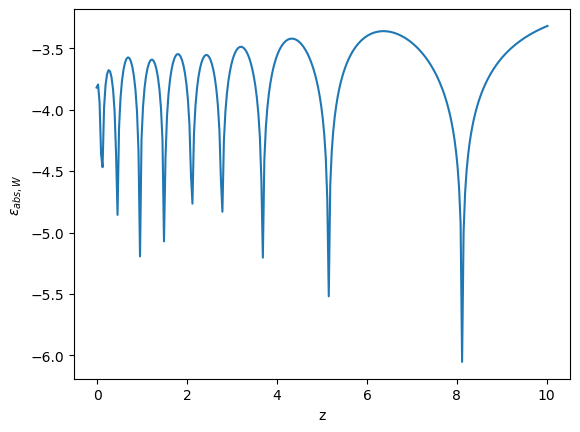

In [19]:
plt.plot(z,err_log)
plt.xlabel('z');plt.ylabel(r'$\varepsilon_{abs,W}$')

In [20]:
U = output*tv[1]

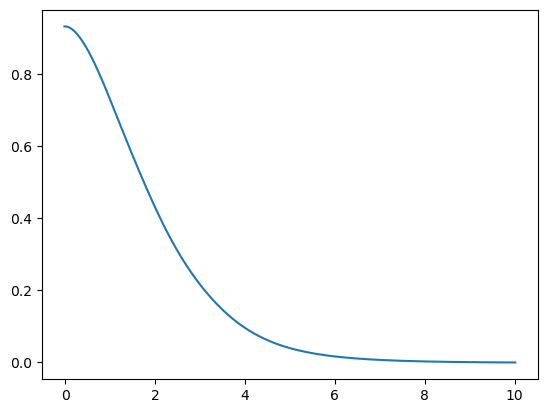

In [16]:
plt.plot(z.detach().numpy(),U.detach().numpy())
